# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [ ]:
import os
import numpy as np
import pandas as pd

from IPython.display import display

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [2]:
tracks = pd.read_parquet("tracks.parquet")
catalog = pd.read_parquet("catalog_names.parquet")
interactions = pd.read_parquet("interactions.parquet")

print(tracks.shape, catalog.shape, interactions.shape)



(1000000, 4) (1812471, 3) (222629898, 4)


In [3]:
display(tracks.head(5))
display(catalog.head(5))
display(interactions.head(5))

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


Уменьшаем кол-во слушателей для облегчения нагрузки на ядро

In [4]:
np.random.seed(42)

users_sample = (
    interactions[["user_id"]]
    .drop_duplicates()
    .sample(n=200_000, random_state=42)
)

interactions_small = interactions.merge(users_sample, on="user_id", how="inner")

interactions_small = (
    interactions_small
    .sort_values(["user_id", "started_at"])
    .groupby("user_id", as_index=False)
    .head(200)
)


interactions_small.shape
interactions_small["user_id"].nunique()



200000

In [5]:
n_users = interactions_small["user_id"].nunique()
n_tracks_events = interactions_small["track_id"].nunique()
n_tracks_items = tracks["track_id"].nunique()

print("unique users in interactions_small:", n_users)
print("unique tracks in interactions_small:", n_tracks_events)
print("unique tracks in tracks.parquet:", n_tracks_items)


unique users in interactions_small: 200000
unique tracks in interactions_small: 644822
unique tracks in tracks.parquet: 1000000


In [6]:
interactions = interactions_small.copy()

# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [7]:
tracks.info()
print('============')
catalog.info()
print('============')
interactions.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 17023467 entries, 0 to 32278239
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1

In [8]:
interactions["track_id"] = interactions["track_id"].astype("int64")
interactions["user_id"] = interactions["user_id"].astype("int64")


In [ ]:
def quick_checks(
    df: pd.DataFrame, name: str, dup_subset=None, null_top: int = 20
) -> None:
    """
    Печатает быстрые проверки качества данных

    Args:
        df (pd.DataFrame): Таблица для проверки
        name (str): Название таблицы для вывода
        dup_subset (list[str] | None): Подмножество колонок для поиска дубликатов (если None, пытается выбрать безопасные колонки)

    Returns:
        None
    """
    print(f"=== {name} ===")
    print("shape:", df.shape)

    # Дубликаты
    if dup_subset is not None:
        dup_cnt = df.duplicated(subset=dup_subset).sum()
        print(f"duplicates (subset={dup_subset}):", int(dup_cnt))
    else:
        try:
            dup_cnt = df.duplicated().sum()
            print("duplicates (all columns):", int(dup_cnt))
        except TypeError:

            def is_hashable_col(s: pd.Series) -> bool:
                x = s.dropna()
                if x.empty:
                    return True
                v = x.iloc[0]
                return not isinstance(v, (list, tuple, set, dict, np.ndarray))

            safe_cols = [c for c in df.columns if is_hashable_col(df[c])]
            dup_cnt = df.duplicated(subset=safe_cols).sum()
            print(f"duplicates (safe columns={safe_cols}):", int(dup_cnt))

    # Пропуски
    nulls = df.isna().sum().sort_values(ascending=False)
    print("nulls (top):")
    display(nulls.head(null_top))
    print()


quick_checks(tracks, "tracks")
quick_checks(catalog, "catalog_names")
quick_checks(interactions, "interactions")

=== tracks ===
shape: (1000000, 4)


duplicates (safe columns=['track_id']): 0
nulls (top):


track_id    0
albums      0
artists     0
genres      0
dtype: int64


=== catalog_names ===
shape: (1812471, 3)
duplicates (all columns): 0
nulls (top):


id      0
type    0
name    0
dtype: int64


=== interactions ===
shape: (17023467, 4)
duplicates (all columns): 0
nulls (top):


user_id       0
track_id      0
track_seq     0
started_at    0
dtype: int64

In [10]:
tracks[["albums","artists","genres"]].head()

def explode_unique_ids(df, col):
    s = df[col].explode()
    s = s.dropna()
    return set(s.unique())

album_ids = explode_unique_ids(tracks, "albums")
artist_ids = explode_unique_ids(tracks, "artists")
genre_ids = explode_unique_ids(tracks, "genres")

print(len(album_ids), len(artist_ids), len(genre_ids))



658724 153581 173


In [11]:
catalog_albums = set(catalog.loc[catalog["type"] == "album", "id"].unique())
catalog_artists = set(catalog.loc[catalog["type"] == "artist", "id"].unique())
catalog_genres = set(catalog.loc[catalog["type"] == "genre", "id"].unique())

missing_albums = album_ids - catalog_albums
missing_artists = artist_ids - catalog_artists
missing_genres = genre_ids - catalog_genres

print("Missing albums:", len(missing_albums))
print("Missing artists:", len(missing_artists))
print("Missing genres:", len(missing_genres))


Missing albums: 0
Missing artists: 0
Missing genres: 30


In [12]:
print("Example missing_genres:", list(missing_genres)[:10])


Example missing_genres: [130, 131, 132, 133, 134, 135, 146, 148, 150, 151]


In [13]:
tracks_with_missing_genres = tracks[
    tracks["genres"].apply(lambda g: any(x in missing_genres for x in g))
]

tracks_with_missing_genres.shape
tracks_with_missing_genres.head()
tracks_with_missing_genres["track_id"].nunique()


48345

In [14]:
tracks_with_missing_genres["track_id"].nunique()


48345

In [15]:
catalog = pd.concat(
    [
        catalog,
        pd.DataFrame({
            "id": list(missing_genres),
            "type": "genre",
            "name": "unknown_genre"
        })
    ],
    ignore_index=True
)


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

Были загружены данные о треках, справочниках и пользовательских взаимодействиях.
Количество уникальных пользователей (около 1,4 млн) и треков (1 млн) соответствует условиям задачи. Пропусков и дубликатов в данных не обнаружено.

Типы данных в целом заданы корректно. Идентификаторы пользователей и треков приведены к единому типу для согласованности между таблицами. В таблице tracks поля с альбомами, артистами и жанрами представлены списками идентификаторов, что было учтено при проверке данных.

В ходе проверки справочников было выявлено, что в catalog_names отсутствуют описания для части жанров. Эти жанры используются в данных о треках и относятся примерно к 48 тыс. треков. Для сохранения целостности данных недостающие жанры были добавлены в справочник с техническим названием unknown_genre.

После выполненных корректировок данные можно считать подготовленными для дальнейших этапов работы.

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

In [ ]:
top_n = 10

In [16]:
# сколько прослушиваний у каждого пользователя
user_listens = interactions.groupby("user_id").size()

user_listens.describe()


count    200000.000000
mean         85.117335
std          71.519932
min           1.000000
25%          23.000000
50%          55.000000
75%         154.000000
max         200.000000
dtype: float64

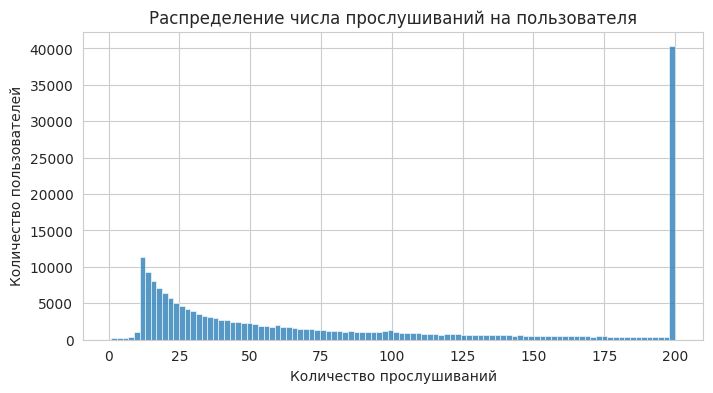

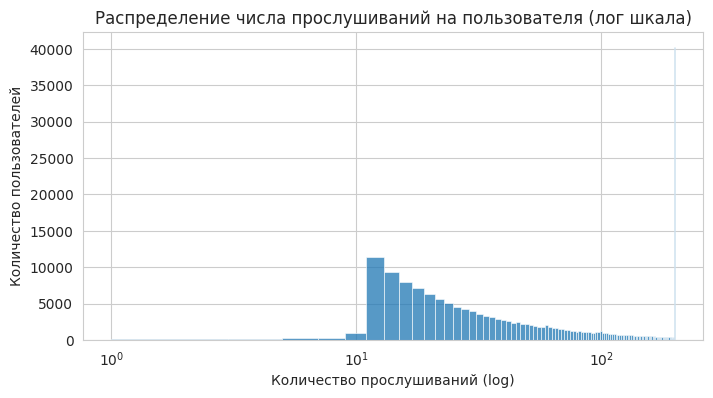

In [17]:
plt.figure(figsize=(8, 4))
sns.histplot(
    user_listens,
    bins=100
)

plt.title("Распределение числа прослушиваний на пользователя")
plt.xlabel("Количество прослушиваний")
plt.ylabel("Количество пользователей")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(
    user_listens,
    bins=100
)

plt.xscale("log")
plt.title("Распределение числа прослушиваний на пользователя (лог шкала)")
plt.xlabel("Количество прослушиваний (log)")
plt.ylabel("Количество пользователей")
plt.show()


Наиболее популярные треки

In [18]:
track_popularity = (
    interactions
    .groupby("track_id")
    .size()
    .reset_index(name="listens")
    .sort_values("listens", ascending=False)
)

track_popularity.head(10)


,track_id,listens
8170,53404,16143
23138,178529,14401
367292,35505245,11574
5941,37384,11545
348956,33311009,11073
73046,795836,10895
33324,328683,10319
7702,48951,10138
343475,32947997,9431
270903,24692821,9416


In [21]:
# получим также и названия для интереса

track_names = catalog[catalog["type"] == "track"][["id", "name"]] \
    .rename(columns={"id": "track_id", "name": "track_name"})


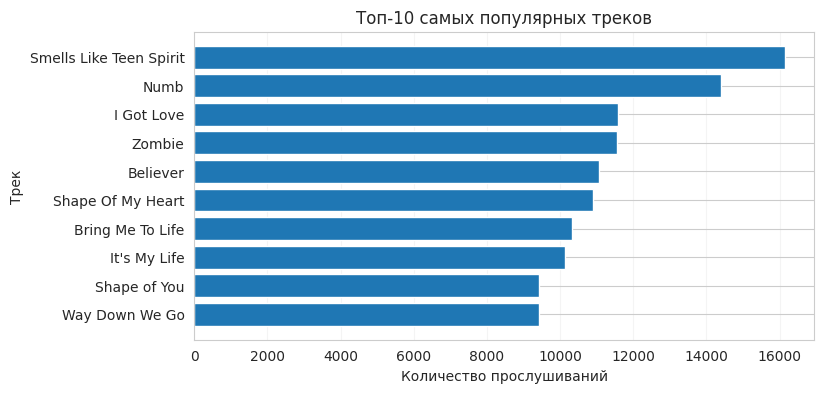

In [ ]:
top_tracks_named = (
    track_popularity
    .head(top_n)
    .merge(track_names, on="track_id", how="left")
)

plt.figure(figsize=(8, 4))
plt.barh(
    top_tracks_named["track_name"].fillna(top_tracks_named["track_id"].astype(str)),
    top_tracks_named["listens"]
)
plt.gca().invert_yaxis()
plt.title(f"Топ-{top_n} самых популярных треков")
plt.xlabel("Количество прослушиваний")
plt.ylabel("Трек")
plt.grid(axis="x", alpha=0.2)
plt.show()

Наиболее популярные жанры

In [ ]:
# минимальный набор для джойна
track_genres = tracks[["track_id", "genres"]]

events_with_genres = interactions[["track_id"]].merge(
    track_genres, on="track_id", how="left"
)

genre_events = events_with_genres.explode("genres")

genre_popularity = (
    genre_events
    .groupby("genres")
    .size()
    .reset_index(name="listens")
    .sort_values("listens", ascending=False)
)

genre_popularity.head(10)


,genres,listens
10,11,4731786
70,75,2713963
95,102,2528897
19,20,2136542
2,3,1772211
63,68,1378108
15,16,1187788
13,14,1162293
1,2,981252
40,44,923519


In [ ]:
genre_names = catalog[catalog["type"] == "genre"][["id", "name"]] \
    .rename(columns={"id": "genre_id", "name": "genre_name"})


top_genres_named = (
    genre_popularity
    .head(top_n)
    .rename(columns={"genres": "genre_id"})
    .merge(genre_names, on="genre_id", how="left")
)

top_genres_named


,genre_id,listens,genre_name
0,11,4731786,pop
1,75,2713963,rap
2,102,2528897,allrock
3,20,2136542,ruspop
4,3,1772211,rusrap
5,68,1378108,electronics
6,16,1187788,dance
7,14,1162293,rock
8,2,981252,rusrock
9,44,923519,foreignrap


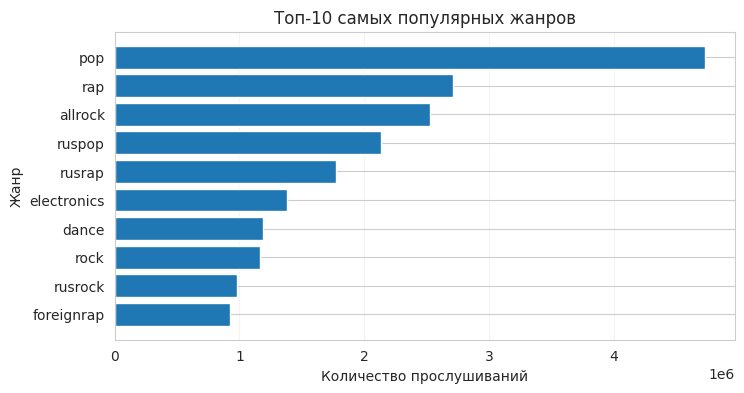

In [25]:
plt.figure(figsize=(8, 4))
plt.barh(
    top_genres_named["genre_name"].fillna("unknown_genre"),
    top_genres_named["listens"]
)
plt.gca().invert_yaxis()
plt.title(f"Топ-{top_n} самых популярных жанров")
plt.xlabel("Количество прослушиваний")
plt.ylabel("Жанр")
plt.grid(axis="x", alpha=0.2)
plt.show()

Треки, которые никто не прослушал

In [28]:
listened_track_ids = interactions["track_id"].unique()

unlistened_tracks = tracks[
    ~tracks["track_id"].isin(listened_track_ids)
]

print(f'не слушали {unlistened_tracks.shape[0]=}')
unlistened_tracks.head()

unlistened_tracks_named = (
    unlistened_tracks
    .merge(
        catalog[catalog["type"] == "track"][["id", "name"]]
        .rename(columns={"id": "track_id", "name": "track_name"}),
        on="track_id",
        how="left"
    )
)

unlistened_tracks_named.head()


не слушали unlistened_tracks.shape[0]=355178


,track_id,albums,artists,genres,track_name
0,26,"[3, 2490753]",[16],"[11, 21]",Complimentary Me
1,136,"[12, 214, 2490809]",[84],[11],24 Hours
2,327,[27],[279],"[38, 47]",Intro
3,329,[27],[279],"[38, 47]",One For Rock & Roll
4,332,[27],[279],"[38, 47]",Don't Know What You Got (Till It's Gone)


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

events — таблица взаимодействий

In [32]:
events = (
    interactions
    .rename(columns={"track_id": "item_id"})
    [["user_id", "item_id", "started_at"]]
)
events = events.sort_values(["user_id", "started_at"])

events.info()
events.head()



<class 'pandas.core.frame.DataFrame'>
Index: 17023467 entries, 0 to 32278239
Data columns (total 3 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int64         
 1   item_id     int64         
 2   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int64(2)
memory usage: 519.5 MB


,user_id,item_id,started_at
0,13,33266,2022-03-13
1,13,597343,2022-03-16
2,13,598400,2022-03-20
3,13,1490932,2022-03-21
4,13,1695466,2022-03-24


items — таблица объектов (треков)

In [ ]:
items = tracks.rename(columns={"track_id": "item_id"})

items.info()
items.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column   Non-Null Count    Dtype 
---  ------   --------------    ----- 
 0   item_id  1000000 non-null  int64 
 1   albums   1000000 non-null  object
 2   artists  1000000 non-null  object
 3   genres   1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


,item_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [11]:
from dotenv import load_dotenv, find_dotenv
import os

env_path = find_dotenv()
print("dotenv path:", env_path)

load_dotenv(env_path, override=True)

print("AWS_ACCESS_KEY_ID:", bool(os.getenv("AWS_ACCESS_KEY_ID")))
print("AWS_SECRET_ACCESS_KEY:", bool(os.getenv("AWS_SECRET_ACCESS_KEY")))
print("AWS_DEFAULT_REGION:", os.getenv("AWS_DEFAULT_REGION"))
print("MLFLOW_S3_ENDPOINT_URL:", os.getenv("MLFLOW_S3_ENDPOINT_URL"))
print("BUCKET:", os.getenv("BUCKET"))


dotenv path: /home/mle-user/mle-project-sprint-4-v001/.env
AWS_ACCESS_KEY_ID: True
AWS_SECRET_ACCESS_KEY: True
AWS_DEFAULT_REGION: ru-central1
MLFLOW_S3_ENDPOINT_URL: https://storage.yandexcloud.net
BUCKET: s3-student-mle-20250327-bdb0de1627


In [ ]:
storage_opts = {
    "key": os.getenv("AWS_ACCESS_KEY_ID"),
    "secret": os.getenv("AWS_SECRET_ACCESS_KEY"),
    "client_kwargs": {
        "endpoint_url": os.getenv("MLFLOW_S3_ENDPOINT_URL"),
        "region_name": os.getenv("AWS_DEFAULT_REGION"),
    },
}

BASE_PATH = f"s3://{os.getenv('BUCKET')}/recsys/data/"

items.to_parquet(
    BASE_PATH + "items.parquet",
    index=False,
    storage_options=storage_opts,
)

events.to_parquet(
    BASE_PATH + "events.parquet",
    index=False,
    storage_options=storage_opts,
)


# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

Можно перезапустить kernel и следующий этап начинать сразу, без возврата к началу

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [ ]:
import os
import numpy as np
import pandas as pd

import scipy.sparse as sp
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

from catboost import CatBoostClassifier
from implicit.als import AlternatingLeastSquares

from dotenv import load_dotenv, find_dotenv
import os

env_path = find_dotenv()
print("dotenv path:", env_path)


dotenv path: /home/mle-user/mle-project-sprint-4-v001/.env


In [16]:
# настройки доступа к S3

load_dotenv(env_path, override=True)
storage_opts = {
    "key": os.getenv("AWS_ACCESS_KEY_ID"),
    "secret": os.getenv("AWS_SECRET_ACCESS_KEY"),
    "client_kwargs": {
        "endpoint_url": os.getenv("MLFLOW_S3_ENDPOINT_URL"),
        "region_name": os.getenv("AWS_DEFAULT_REGION"),
    },
}

BUCKET = os.getenv("BUCKET")
BASE_DATA = f"s3://{BUCKET}/recsys/data/"
BASE_RECS = f"s3://{BUCKET}/recsys/recommendations/"


In [17]:
# читаем подготовленные таблицы
items = pd.read_parquet(BASE_DATA + "items.parquet", storage_options=storage_opts)
events = pd.read_parquet(BASE_DATA + "events.parquet", storage_options=storage_opts)

# контроль типов
events["user_id"] = events["user_id"].astype("int64")
events["item_id"] = events["item_id"].astype("int64")
events["started_at"] = pd.to_datetime(events["started_at"])
items["item_id"] = items["item_id"].astype("int64")


In [27]:
items

,item_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]
...,...,...,...,...
999995,101478482,[21399811],[5540395],"[3, 75]"
999996,101490148,[21403052],[9078726],"[11, 20]"
999997,101493057,[21403883],[11865715],"[44, 75]"
999998,101495927,[21404975],[4462686],"[3, 75]"


In [28]:
events

,user_id,item_id,started_at
0,13,33266,2022-03-13
1,13,597343,2022-03-16
2,13,598400,2022-03-20
3,13,1490932,2022-03-21
4,13,1695466,2022-03-24
...,...,...,...
17023462,1374580,52633205,2022-08-02
17023463,1374580,53298351,2022-08-02
17023464,1374580,53357546,2022-08-05
17023465,1374580,53694971,2022-08-05


# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [ ]:
split_dt = pd.to_datetime("2022-12-16")

# разбиение
events_train = events[events["started_at"] < split_dt].copy()
events_test = events[events["started_at"] >= split_dt].copy()

# быстрые проверки
print("split_dt:", split_dt)
print("events_train:", len(events_train))
print("events_test :", len(events_test))

print("users_train:", events_train["user_id"].nunique())
print("users_test :", events_test["user_id"].nunique())

print("items_train:", events_train["item_id"].nunique())
print("items_test :", events_test["item_id"].nunique())

print("train date range:", events_train["started_at"].min(), ":", events_train["started_at"].max())
print("test  date range:", events_test["started_at"].min(), ":", events_test["started_at"].max())


split_dt: 2022-12-16 00:00:00
events_train: 16023449
events_test : 1000018
users_train: 195633
users_test : 92663
items_train: 619783
items_test : 191110
train date range: 2022-01-01 00:00:00 -> 2022-12-15 00:00:00
test  date range: 2022-12-16 00:00:00 -> 2022-12-31 00:00:00


# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [29]:
top_k = 100

item_popularity = (
    events_train
    .groupby("item_id")
    .agg(users=("user_id", "nunique"))
    .reset_index()
    .sort_values("users", ascending=False)
)

top_pop_items = item_popularity.head(top_k).copy()

# score оставляем числовым для совместимости с метриками
top_pop_items["score"] = top_pop_items["users"].astype("float")

top_pop_items = top_pop_items[["item_id", "score"]].reset_index(drop=True)

print(top_pop_items.head())
print("top_pop_items:", len(top_pop_items))


    item_id    score
0     53404  16000.0
1    178529  14233.0
2     37384  11461.0
3  35505245  11069.0
4    795836  10710.0
top_pop_items: 100


In [30]:
# пользователи, для которых будем оценивать рекомендации
test_users = events_test[["user_id"]].drop_duplicates()

top_popular_recs = test_users.merge(top_pop_items, how="cross")

# ранжирование внутри пользователя
top_popular_recs["rank"] = (
    top_popular_recs
    .groupby("user_id")["score"]
    .rank(method="first", ascending=False)
    .astype("int64")
)

top_popular_recs = top_popular_recs[["user_id", "item_id", "score", "rank"]]

print("rows:", len(top_popular_recs))
print("users:", top_popular_recs["user_id"].nunique())
print(
    "items per user:",
    top_popular_recs.groupby("user_id")["item_id"].count().min(),
    top_popular_recs.groupby("user_id")["item_id"].count().max(),
)


rows: 9266300
users: 92663
items per user: 100 100


In [32]:
top_popular_recs.to_parquet(
    BASE_RECS + "top_popular.parquet",
    index=False,
    storage_options=storage_opts,
)


# Персональные

Рассчитаем персональные рекомендации.

In [35]:
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

user_encoder.fit(events_train["user_id"])
item_encoder.fit(events_train["item_id"])

events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"])
events_train["item_id_enc"] = item_encoder.transform(events_train["item_id"])

n_users = events_train["user_id_enc"].nunique()
n_items = events_train["item_id_enc"].nunique()

print("n_users:", n_users)
print("n_items:", n_items)


n_users: 195633
n_items: 619783


In [ ]:
# формирование user-item матрицы взаимодействий в sparse-формате
user_item_matrix = sp.csr_matrix(
    (
        np.ones(len(events_train), dtype=np.float32),
        (
            events_train["user_id_enc"],
            events_train["item_id_enc"],
        ),
    ),
    shape=(n_users, n_items),
)
print(user_item_matrix.shape)
print("nnz:", user_item_matrix.nnz)


(195633, 619783)
nnz: 16023449


In [37]:
als_model = AlternatingLeastSquares(
    factors=50,
    iterations=20,
    regularization=0.05,
    random_state=42,
)

als_model.fit(user_item_matrix)

/home/mle-user/env_recsys_start/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 20/20 [01:44<00:00,  5.23s/it]


In [38]:
# пользователи теста, которые есть в train
test_users = (
    events_test[["user_id"]]
    .drop_duplicates()
    .query("user_id in @user_encoder.classes_")
)

test_users["user_id_enc"] = user_encoder.transform(test_users["user_id"])



In [ ]:
als_recs = als_model.recommend(
    test_users["user_id_enc"].to_numpy(),
    user_item_matrix[test_users["user_id_enc"]],
    N=top_k,
    filter_already_liked_items=True,
)


In [ ]:
# рекомендации ALS возвращаются в виде массивов:
# item_ids_enc - закодированные идентификаторы айтемов
# scores - соответствующие им оценки модели
item_ids_enc = als_recs[0]
scores = als_recs[1]

personal_als = pd.DataFrame(
    {
        "user_id_enc": test_users["user_id_enc"].to_numpy(),
        "item_id_enc": item_ids_enc.tolist(),
        "score": scores.tolist(),
    }
).explode(["item_id_enc", "score"], ignore_index=True)

personal_als["item_id_enc"] = personal_als["item_id_enc"].astype("int64")
personal_als["score"] = personal_als["score"].astype("float")

personal_als["user_id"] = user_encoder.inverse_transform(personal_als["user_id_enc"])
personal_als["item_id"] = item_encoder.inverse_transform(personal_als["item_id_enc"])

personal_als = personal_als[["user_id", "item_id", "score"]]

In [ ]:
personal_als = personal_als.sort_values(
    ["user_id", "score"],
    ascending=[True, False],
)

# присвоение рангов рекомендациям внутри каждого пользователя
personal_als["rank"] = (
    personal_als
    .groupby("user_id")
    .cumcount()
    + 1
)

print("rows:", len(personal_als))
print("users:", personal_als["user_id"].nunique())
print(
    "items per user:",
    personal_als.groupby("user_id")["item_id"].count().min(),
    personal_als.groupby("user_id")["item_id"].count().max(),
)


rows: 8829600
users: 88296
items per user: 100 100


In [42]:
personal_als

,user_id,item_id,score,rank
0,13,9282507,0.400962,1
1,13,2200948,0.273132,2
2,13,17198356,0.266928,3
3,13,6024175,0.240070,4
4,13,24112220,0.216607,5
...,...,...,...,...
8829595,1374530,1710804,0.124907,96
8829596,1374530,610031,0.123298,97
8829597,1374530,30298,0.123090,98
8829598,1374530,558821,0.122434,99


In [45]:
personal_als.to_parquet(
    BASE_RECS + "personal_als.parquet",
    index=False,
    storage_options=storage_opts,
)


# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [ ]:
train_item_ids_enc = np.unique(events_train["item_id_enc"].to_numpy())
max_similar_items = int(top_k / 2) #  тут уменьшаем, иначе очень долго будет считаться

batch_size = 5000

Расчёт похожих айтемов через ALS батчами, чтобы не держать всё в памяти разом, similar_items возвращает для каждого item_id_enc список из N похожих item_id_enc и их score


In [51]:
rows = []

for start in range(0, len(train_item_ids_enc), batch_size):
    batch = train_item_ids_enc[start:start + batch_size]

    sim_ids, sim_scores = als_model.similar_items(batch, N=max_similar_items + 1)

    df = pd.DataFrame({
        "item_id_enc": batch,
        "sim_item_id_enc": sim_ids.tolist(),
        "score": sim_scores.tolist(),
    })

    df = df.explode(["sim_item_id_enc", "score"], ignore_index=True)
    df["sim_item_id_enc"] = df["sim_item_id_enc"].astype("int64")
    df["score"] = df["score"].astype("float")

    rows.append(df)

    if (start // batch_size) % 10 == 0:
        print("processed:", start, "of", len(train_item_ids_enc))


processed: 0 of 619783
processed: 50000 of 619783
processed: 100000 of 619783
processed: 150000 of 619783
processed: 200000 of 619783
processed: 250000 of 619783
processed: 300000 of 619783
processed: 350000 of 619783
processed: 400000 of 619783
processed: 450000 of 619783
processed: 500000 of 619783
processed: 550000 of 619783
processed: 600000 of 619783


In [ ]:
similar_items = pd.concat(rows, ignore_index=True)

# удаление self-match: модель возвращает сам айтем как наиболее похожий
similar_items = similar_items[
    similar_items["sim_item_id_enc"] != similar_items["item_id_enc"]
].copy()

similar_items = similar_items.sort_values(
    ["item_id_enc", "score"], ascending=[True, False]
)
similar_items["rank"] = similar_items.groupby("item_id_enc").cumcount() + 1
similar_items = similar_items.query("rank <= @max_similar_items").copy()

# декодирование идентификаторов айтемов в исходные значения
similar_items["item_id"] = item_encoder.inverse_transform(similar_items["item_id_enc"])
similar_items["similar_item_id"] = item_encoder.inverse_transform(
    similar_items["sim_item_id_enc"]
)

similar_items = similar_items[["item_id", "similar_item_id", "score", "rank"]]

print("rows:", len(similar_items))
print("items:", similar_items["item_id"].nunique())
print(
    "per item min/max:",
    similar_items.groupby("item_id")["similar_item_id"].count().min(),
    similar_items.groupby("item_id")["similar_item_id"].count().max(),
)

rows: 30989150
items: 619783
per item min/max: 50 50


In [53]:
similar_items.to_parquet(
    BASE_RECS + "similar.parquet",
    index=False,
    storage_options=storage_opts,
)


Похожие треки рассчитаны методом ALS similar_items, по 50 кандидатов на каждый трек из train, self-match исключён.

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

Контентные признаки (артисты, жанры, альбомы) не используются на данном этапе, так как они применимы для генерации рекомендаций, а не для ранжирования кандидатов, полученных коллаборативными методами.

Признаки для ранжирования:
- als_score — скор персональной ALS-модели
- item_users — популярность трека (число уникальных пользователей)
- user_events — активность пользователя


In [ ]:
# список пользователей для ранжирования (берём пользователей из тестовой выборки)
test_users = events_test[["user_id"]].drop_duplicates()

# кандидаты от ALS
candidates_als = (
    personal_als
    .rename(columns={"score": "als_score"})
    .loc[:, ["user_id", "item_id", "als_score"]]
)

# кандидаты от top popular
candidates_top = (
    test_users
    .merge(top_pop_items[["item_id", "score"]], how="cross")
    .rename(columns={"score": "pop_score"})
)
candidates_top["als_score"] = 0.0
candidates_top = candidates_top[["user_id", "item_id", "als_score"]]

# объединение кандидатов и удаление дублей
candidates = (
    pd.concat([candidates_als, candidates_top], ignore_index=True)
    .drop_duplicates(["user_id", "item_id"])
)

# признаки объектов: популярность трека в обучающей выборке
item_popularity = (
    events_train
    .groupby("item_id")
    .agg(item_users=("user_id", "nunique"))
    .reset_index()
)

# признаки пользователей: активность пользователя в обучающей выборке
user_activity = (
    events_train
    .groupby("user_id")
    .agg(user_events=("item_id", "count"))
    .reset_index()
)

# присоединение признаков к кандидатам
candidates = (
    candidates
    .merge(item_popularity, on="item_id", how="left")
    .merge(user_activity, on="user_id", how="left")
)

# заполнение пропусков для кандидатов, отсутствующих в обучающей выборке по item_id или user_id
candidates["item_users"] = candidates["item_users"].fillna(0).astype("int64")
candidates["user_events"] = candidates["user_events"].fillna(0).astype("int64")

# итоговый список признаков для ранжирования
features = ["als_score", "item_users", "user_events"]

print("candidates rows:", len(candidates))
print("unique users:", candidates["user_id"].nunique())
print("unique items:", candidates["item_id"].nunique())
candidates.head()


candidates rows: 16712538
unique users: 92663
unique items: 4614


,user_id,item_id,als_score,item_users,user_events
0,13,9282507,0.400962,5950,133
1,13,2200948,0.273132,3080,133
2,13,17198356,0.266928,3790,133
3,13,6024175,0.240070,3352,133
4,13,24112220,0.216607,2301,133


# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [ ]:
# target = 1, если пользователь взаимодействовал с треком в test-периоде
events_test_targets = (
    events_test
    .assign(target=1)
    .loc[:, ["user_id", "item_id", "target"]]
)

candidates = (
    candidates
    .merge(events_test_targets, on=["user_id", "item_id"], how="left")
)

candidates["target"] = candidates["target"].fillna(0).astype("int8")

X = candidates[features]
y = candidates["target"]

ranker = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=50
)

# обучение модели
ranker.fit(X, y)

# сохранение предсказаний
candidates["rank_score"] = ranker.predict_proba(X)[:, 1]

# финальное ранжирование рекомендаций
final_recommendations = (
    candidates
    .sort_values(["user_id", "rank_score"], ascending=[True, False])
    .assign(rank=lambda df: df.groupby("user_id").cumcount() + 1)
)

# ограничение количества рекомендаций на пользователя
top_k = 100
final_recommendations = final_recommendations.query("rank <= @top_k")

print("final rows:", len(final_recommendations))
print("users:", final_recommendations["user_id"].nunique())
print(
    "items per user (min/max):",
    final_recommendations.groupby("user_id")["item_id"].count().min(),
    final_recommendations.groupby("user_id")["item_id"].count().max(),
)

final_recommendations.head()


0:	total: 1.38s	remaining: 6m 53s
50:	total: 1m 8s	remaining: 5m 35s
100:	total: 2m 21s	remaining: 4m 38s
150:	total: 3m 38s	remaining: 3m 35s
200:	total: 5m	remaining: 2m 28s
250:	total: 6m 20s	remaining: 1m 14s
299:	total: 7m 44s	remaining: 0us
final rows: 9266300
users: 92663
items per user (min/max): 100 100


,user_id,item_id,als_score,item_users,user_events,target,rank_score,rank
51,13,10267566,0.129417,1036,133,0,0.015136,1
3,13,6024175,0.240070,3352,133,0,0.010572,2
1,13,2200948,0.273132,3080,133,0,0.010488,3
5,13,17887582,0.213693,2577,133,0,0.010024,4
24,13,50684233,0.151747,3197,133,0,0.009993,5


# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [ ]:
# Оценка качества рекомендаций: precision, recall, coverage, novelty

k = 100

# тестовая релевантность: что реально случилось в test
gt = (
    events_test
    .groupby("user_id")["item_id"]
    .apply(set)
    .to_dict()
)

# популярность айтемов в train для novelty
item_pop = (
    events_train
    .groupby("item_id")["user_id"]
    .nunique()
    .rename("train_users")
    .reset_index()
)
total_users_train = events_train["user_id"].nunique()
item_pop["p"] = item_pop["train_users"] / total_users_train
item_pop["novelty"] = -np.log2(item_pop["p"].clip(lower=1e-12))
item_novelty = item_pop.set_index("item_id")["novelty"].to_dict()

all_train_items = set(events_train["item_id"].unique())

def prepare_recs_top_pop(top_pop_items, users_df, k):
    recs = users_df.merge(top_pop_items[["item_id"]], how="cross")
    recs["rank"] = recs.groupby("user_id").cumcount() + 1
    recs = recs.query("rank <= @k")
    return recs[["user_id", "item_id", "rank"]]

def prepare_recs_scored(recs_df, score_col, k):
    recs = (
        recs_df
        .sort_values(["user_id", score_col], ascending=[True, False])
        .assign(rank=lambda df: df.groupby("user_id").cumcount() + 1)
        .query("rank <= @k")
    )
    return recs[["user_id", "item_id", "rank"]]

def compute_metrics(recs, gt_dict, all_items_train, novelty_dict, k):
    users = recs["user_id"].unique()
    users_set = set(users)

    # coverage: доля уникальных айтемов в рекомендациях от всех айтемов train
    rec_items = set(recs["item_id"].unique())
    coverage = len(rec_items) / max(1, len(all_items_train))

    # precision/recall: по пользователям
    recs_by_user = recs.groupby("user_id")["item_id"].apply(list).to_dict()

    precisions = []
    recalls = []
    novelties = []

    for u in users:
        rec_list = recs_by_user.get(u, [])
        rec_set = set(rec_list)

        gt_set = gt_dict.get(u, set())
        hits = len(rec_set & gt_set)

        precisions.append(hits / k)

        denom = len(gt_set)
        recalls.append(hits / denom if denom > 0 else np.nan)

        # novelty: средняя неожиданность по рекомендованным айтемам
        if len(rec_list) > 0:
            nov = [novelty_dict.get(i, 0.0) for i in rec_list]
            novelties.append(float(np.mean(nov)))
        else:
            novelties.append(np.nan)

    precision = float(np.nanmean(precisions))
    recall = float(np.nanmean(recalls))
    novelty = float(np.nanmean(novelties))

    return {
        "precision": precision,
        "recall": recall,
        "coverage": coverage,
        "novelty": novelty,
        "users": int(len(users_set)),
        "recs_rows": int(len(recs))
    }

# пользователи, для которых считаем метрики (пересечение: есть тест)
users_for_eval = events_test[["user_id"]].drop_duplicates()

# 1) топ популярных
top_pop_recs = prepare_recs_top_pop(top_pop_items=top_pop_items, users_df=users_for_eval, k=k)

# 2) персональные ALS
personal_als_recs = prepare_recs_scored(personal_als, score_col="score", k=k)

# 3) итоговые ранжированные
score_col_final = "rank_score" if "rank_score" in final_recommendations.columns else (
    "cb_score" if "cb_score" in final_recommendations.columns else "score"
)
final_recs = prepare_recs_scored(final_recommendations.rename(columns={score_col_final: "score"}), score_col="score", k=k)

metrics_top = compute_metrics(top_pop_recs, gt, all_train_items, item_novelty, k)
metrics_als = compute_metrics(personal_als_recs, gt, all_train_items, item_novelty, k)
metrics_final = compute_metrics(final_recs, gt, all_train_items, item_novelty, k)

results = pd.DataFrame([
    {"model": "top_popular", **metrics_top},
    {"model": "personal_als", **metrics_als},
    {"model": "final_ranked", **metrics_final},
])

results


,model,precision,recall,coverage,novelty,users,recs_rows
0,top_popular,0.002569,0.020249,0.000161,4.850213,92663,9266300
1,personal_als,0.006035,0.091311,0.007445,6.251719,88296,8829600
2,final_ranked,0.006953,0.092992,0.007445,6.065648,92663,9266300


# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.


В рамках проекта были использованы три подхода для рекомендаций:

- **Top popular**
- **Персональные рекомендации на основе ALS**
- **Итоговые рекомендации с двухстадийным ранжированием**

### Top popular

Рекомендации, основанные исключительно на популярности, показали:

- минимальные значения precision и recall;
- крайне низкое покрытие каталога;
- наименьшую novelty.

Модель рекомендует один и тот же набор наиболее популярных треков всем пользователям, практически не обеспечивая персонализации. Этот подход можем использовать как бейзлайн для первоначальных метрик.

### Персональные рекомендации (ALS)

При использовании ALS было получено улучшение качества рекомендаций:

- recall вырос более чем в 4 раза по сравнению с top popular;
- coverage увеличился на порядок;
- novelty стала максимальной среди всех подходов.

Т.е. подтверждаем способность ALS формировать более разнообразные рекомендации в сравнении с top popular. При этом наблюдается снижение охвата пользователей, связанное с проблемой холодного старта, что является характерным ограничением данного подхода.
Также пришлось уменьшать количество бачей и топов, чтобы пролезало по памяти и времени выполнния.

### Итоговые рекомендации с двухстадийным ранжированием

Двухстадийный подход с ранжированием кандидатов показал наилучший баланс метрик:

- precision и recall достигли максимальных значений среди всех рассмотренных моделей;
- coverage сохранился на уровне ALS;
- novelty немного снизилась, что отражает компромисс между новизной и вероятностью взаимо
